## Import Libraries

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [ ]:
import numpy as np
import pandas as pd
import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

## Load Result Data

In [ ]:
common_path = '/content/gdrive/MyDrive/csv_results/'

In [ ]:
df_aenet = pd.read_csv(f'{common_path}AENet_protIQA_trCeAS_tsCeAS.csv', index_col=False).sort_values(by='full_path_iqa').reset_index(drop=True)
df_our = pd.read_csv(f'{common_path}PhD4_protIQA_trCeAS_tsIQA.csv', index_col=False).sort_values(by='full_path_iqa').reset_index(drop=True)
df_iqa = pd.read_csv(f'{common_path}IQDmb_protIQA_trfasIQA_tsfasIQA.csv', index_col=False).sort_values(by='full_path_iqa').reset_index(drop=True)

In [ ]:
msu_dict = {
    'SD': 'real',
    'video': 'replay',
    'photo': 'print'
}

ceas_dict = {
    'Spt0': 'real',
    'Spt1': 'print',
    'Spt2': 'print',
    'Spt3': 'print',
    'Spt4': 'paper_cut',
    'Spt5': 'paper_cut',
    'Spt6': 'paper_cut',
    'Spt7': 'replay',
    'Spt8': 'replay',
    'Spt9': 'replay',
    'Spt10': '3d',
}

## Prepare Data

In [ ]:
df_aenet.label_predict_proba = df_aenet.label_predict_proba.apply(lambda x: eval(x) if str(x)!='nan' else np.nan)
df_aenet.label_predict_proba = df_aenet.label_predict_proba.apply(lambda x: [x[0]])
df_aenet.head(1)

,filename,scene,label,data_type,distortion_type,label_iqa,full_path_iqa,label_predict_proba
0,BlurX_11_f_frame_187.jpg,attack_client001_android_SD_ipad_video_scene01,attack,test,BlurX,BlurX_11,fas_iqa_dataset/BlurX/test/attack/attack_clien...,[0.00044815815635956824]


In [ ]:
df_our.liveness_final_pred = df_our.liveness_final_pred.apply(lambda x: eval(x) if str(x)!='nan' else np.nan)

mean_liveness_our = np.mean(df_our.liveness_final_pred.tolist(), axis=1)
std_liveness_our = np.std(df_our.liveness_final_pred.tolist(), axis=1)
newmean_liveness_our = mean_liveness_our*(std_liveness_our<0.15).astype(int)

df_our.liveness_final_pred = newmean_liveness_our.tolist()
df_our.liveness_final_pred = df_our.liveness_final_pred.apply(lambda x: [x])

df_our.head(1)

,filename,scene,label,data_type,distortion_type,label_iqa,full_path_iqa,paper_pred,mask_pred,replay_pred,liveness_pred,liveness_final_pred
0,BlurX_11_f_frame_187.jpg,attack_client001_android_SD_ipad_video_scene01,attack,test,BlurX,BlurX_11,fas_iqa_dataset/BlurX/test/attack/attack_clien...,"[0.9998691082000732, 0.9997979998588562, 0.998...","[0.9999725818634033, 0.9999860525131226, 0.999...","[0.10723491758108139, 0.17952661216259003, 0.0...","[0.37924984097480774, 0.2846536934375763, 0.18...",[0.055620809979736806]


In [ ]:
df_iqa.label_pred_proba_original = df_iqa.label_pred_proba_original.apply(lambda x: [x])
df_iqa.head(1)

,filename,scene,label,data_type,distortion_type,label_iqa,full_path_iqa,label_pred,label_pred_proba_max,label_pred_proba,label_pred_proba_original
0,BlurX_11_f_frame_187.jpg,attack_client001_android_SD_ipad_video_scene01,attack,test,BlurX,BlurX_11,fas_iqa_dataset/BlurX/test/attack/attack_clien...,BlurX_11,0.999999,"[6.554751852405616e-09, 1.2337497690140253e-10...",[1.2046483255367946e-10]


In [ ]:
df_all_iqa_fusion = df_aenet.copy()
df_all_iqa_fusion['spoofing_label'] = df_aenet.label.apply(lambda x: 1 if x.lower() in ['real', 'live'] else 0)
df_all_iqa_fusion['spoof_type'] = df_aenet.scene.apply(lambda x: msu_dict[x.split('_')[-2]] if 'scene' in x else ceas_dict[x.split('_')[-1]])

df_all_iqa_fusion['ceas_label_predict_proba'] = df_aenet.label_predict_proba
df_all_iqa_fusion['our_label_predict_proba'] = df_our.liveness_final_pred
df_all_iqa_fusion['iqa_label_predict_proba'] = df_iqa.label_pred_proba_original
df_all_iqa_fusion['id_sample'] = df_all_iqa_fusion.index.astype(str)
df_all_iqa_fusion['id_sample'] = df_all_iqa_fusion.id_sample.apply(lambda x: 'id_' + ('0'*20 + x)[-6:])

# df_all_iqa_fusion.head(3)

In [ ]:
# Select only images from CelebA-Spoof
df_all_iqa_fusion = df_all_iqa_fusion[~df_all_iqa_fusion.scene.str.contains('scene')]

In [ ]:
df_all_iqa_fusion.shape

(50000, 14)

In [ ]:
df_real_iqa_spoof = df_all_iqa_fusion[df_all_iqa_fusion.spoofing_label==1]
df_attack_iqa_spoof = df_all_iqa_fusion[df_all_iqa_fusion.spoofing_label==0]

In [ ]:
OUR_AND_IQA_real = {
  "similarity_scores": {
    "type": "mated", # FRR
    "scores_by_pair_ids": dict(zip(df_real_iqa_spoof.id_sample, df_real_iqa_spoof.our_label_predict_proba.apply(lambda x: x[0]))),
  },
  "quality_scores_by_sample_id_per_algorithm": {
    "IQ-Model-MbNv2": dict(zip(df_real_iqa_spoof.id_sample, df_real_iqa_spoof.iqa_label_predict_proba.apply(lambda x: x[0]))),
  }
}

AEnet_AND_IQA_real = {
  "similarity_scores": {
    "type": "mated", # FRR
    "scores_by_pair_ids": dict(zip(df_real_iqa_spoof.id_sample, df_real_iqa_spoof.ceas_label_predict_proba.apply(lambda x: x[0]))),
  },
  "quality_scores_by_sample_id_per_algorithm": {
    "IQ-Model-MbNv2": dict(zip(df_real_iqa_spoof.id_sample, df_real_iqa_spoof.iqa_label_predict_proba.apply(lambda x: x[0]))),
  }
}

In [ ]:
OUR_AND_IQA_attack_st = {}
AEnet_AND_IQA_attack_st = {}
for i_st in df_attack_iqa_spoof.spoof_type.unique():
    df_attack_iqa_spoof_tmp = df_attack_iqa_spoof[df_attack_iqa_spoof.spoof_type==i_st]
    OUR_AND_IQA_attack_st[i_st] = {
            "similarity_scores": {
                "type": "nonmated", # FAR
                "scores_by_pair_ids": dict(zip(df_attack_iqa_spoof_tmp.id_sample, df_attack_iqa_spoof_tmp.our_label_predict_proba.apply(lambda x: x[0]))),
            },
            "quality_scores_by_sample_id_per_algorithm": {
                "IQ-Model-MbNv2": dict(zip(df_attack_iqa_spoof_tmp.id_sample, df_attack_iqa_spoof_tmp.iqa_label_predict_proba.apply(lambda x: x[0]))),
            }
            }
    AEnet_AND_IQA_attack_st[i_st] = {
            "similarity_scores": {
                "type": "nonmated", # FAR
                "scores_by_pair_ids": dict(zip(df_attack_iqa_spoof_tmp.id_sample, df_attack_iqa_spoof_tmp.ceas_label_predict_proba.apply(lambda x: x[0]))),
            },
            "quality_scores_by_sample_id_per_algorithm": {
                "IQ-Model-MbNv2": dict(zip(df_attack_iqa_spoof_tmp.id_sample, df_attack_iqa_spoof_tmp.iqa_label_predict_proba.apply(lambda x: x[0]))),
            }
            }

In [ ]:
value_op_list = [0.0, 0.2, 0.4, 0.6, 0.8, 0.95, 0.97]

# EDC Functions

The codes and functions used to calculate the metrics using the EDC approach are based on the https://github.com/dasec/quality-assessment-evaluation repository, please check it for more details. Several modifications were made to the original code in order to adapt it to the metrics of facial anti-spoofing systems.


##### Imports

In [ ]:
!git clone https://github.com/dasec/quality-assessment-evaluation.git

Cloning into 'quality-assessment-evaluation'...
remote: Enumerating objects: 14, done.
remote: Counting objects: 100% (14/14), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 14 (delta 2), reused 11 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (14/14), 514.88 KiB | 18.39 MiB/s, done.
Resolving deltas: 100% (2/2), done.


In [ ]:
!mv quality-assessment-evaluation/ iqa_eval/

In [ ]:
import iqa_eval.edc as edc

In [ ]:
import json

import plotly as plty
import plotly.graph_objects as go
import tqdm

from iqa_eval.edc import EdcErrorType
from iqa_eval.edc import EdcSample
from iqa_eval.edc import EdcSamplePair
from iqa_eval.edc import EdcOutput
from iqa_eval.edc import compute_edc
from iqa_eval.edc import compute_edc_pauc
from iqa_eval.edc import compute_edc_area_under_theoretical_best

### EDC Functions

In [ ]:
comparison_type_to_error_type = {
    'mated': EdcErrorType.FNMR,
    'nonmated': EdcErrorType.FMR,
}

metrics_name_dict = {
    'FMR': 'APCER',#'FAR',
    'FNMR': 'BPCER',#'FRR'
}

In [ ]:
def _min_max_normalize(quality_scores: dict, bin_count: int) -> dict:
  value_min = min(quality_scores.values())
  value_max = max(quality_scores.values())
  value_range = value_max - value_min
  return {
      sample_id: round(bin_count * ((quality_score - value_min) / value_range))
      for sample_id, quality_score in quality_scores.items()
  }


def _create_edc_plot(
    error_type: EdcErrorType,
    edc_outputs: dict,
    starting_error: float,
    pauc_values: dict,
    pauc_discard_limit: float,
    shade_pauc: bool = True,
) -> go.Figure():
  """Create a go.Figure() and plot the EDC curves, including the pAUC for the best curve."""
  figure = go.Figure()

  figure.add_trace(
      go.Scatter(
          x=[0, 1],
          y=[starting_error, starting_error],
          opacity=0.7,
          showlegend=False,
          line=dict(dash='dash', color='gray'),
      ))

  figure.add_trace(
      go.Scatter(
          x=[0, starting_error],
          y=[starting_error, 0],
          opacity=0.7,
          showlegend=False,
          line=dict(dash='dash', color='gray'),
      ))

  if shade_pauc:
    best_edc_output = _get_best_edc_output(edc_outputs, pauc_values)
    _plot_shaded_pauc(
        figure=figure,
        edc_output=best_edc_output,
        pauc_discard_limit=pauc_discard_limit,
        starting_error=starting_error,
    )

  relative_rankings = _compute_relative_rankings(pauc_values)
  for i, (quality_assessment_algorithm, edc_output) in enumerate(reversed(edc_outputs.items())):
    discard_fractions = edc_output['discard_fractions']
    error_fractions = edc_output['error_fractions']
    label = (f'{quality_assessment_algorithm}'
             f' | pAUC: {pauc_values[quality_assessment_algorithm]:.4f}'
             f' | Ranking: {relative_rankings[quality_assessment_algorithm]:.2f}')
    line_color = plty.colors.DEFAULT_PLOTLY_COLORS[i % len(plty.colors.DEFAULT_PLOTLY_COLORS)]
    figure.add_trace(
        go.Scatter(
            x=discard_fractions,
            y=error_fractions,
            name=label,
            line_shape='hv',
            line_color=line_color,
        ))

  figure.update_layout(
      template='plotly_white',
      xaxis_title='Fraction of discarded comparisons',
      yaxis_title=metrics_name_dict[error_type.value],

  )
  return figure


def _compute_relative_rankings(pauc_values: dict) -> dict:
  """Min-max normalize the pAUC values as 'relative rankings' (0 being the best algorithm, 1 being the worst)."""
  relative_rankings = {}
  pauc_value_min = min(pauc_values.values())
  pauc_value_max = max(pauc_values.values())
  pauc_value_range = pauc_value_max - pauc_value_min
  for quality_assessment_algorithm, pauc_value in pauc_values.items():
    relative_rankings[quality_assessment_algorithm] = (pauc_value - pauc_value_min) / pauc_value_range
  return relative_rankings


def _get_best_edc_output(edc_outputs: dict, pauc_values: dict) -> EdcOutput:
  """Get the best EdcOutput according to the pAUC values."""
  best_edc_output = None
  best_pauc_value = None
  for quality_assessment_algorithm, pauc_value in pauc_values.items():
    if (best_pauc_value is None) or (pauc_value < best_pauc_value):
      best_pauc_value = pauc_value
      best_edc_output = edc_outputs[quality_assessment_algorithm]
  return best_edc_output


def _plot_shaded_pauc(
    figure: go.Figure,
    edc_output: EdcOutput,
    pauc_discard_limit: float,
    starting_error: float,
):
  """Plot the pAUC in the given figure."""
  pauc_curve = {
      'x': edc_output['discard_fractions'],
      'y': edc_output['error_fractions'],
  }
  pauc_curve = _cut_curve(pauc_curve, x_limit=pauc_discard_limit)
  if pauc_discard_limit <= starting_error:
    curve_x_min = [0, pauc_discard_limit]
    curve_y_min = [starting_error, starting_error - pauc_discard_limit]
  else:
    curve_x_min = [0, starting_error, pauc_discard_limit]
    curve_y_min = [starting_error, 0, 0]
  for trace in _create_area_traces(pauc_curve['x'], pauc_curve['y'], curve_x_min, curve_y_min):
    figure.add_trace(trace)


def _cut_curve(curve: dict, x_limit: float):
  """Utility function to cut a curve for plotting purposes."""
  new_curve = {
      'x': [],
      'y': [],
  }
  index = -1
  while True:
    index += 1
    if index >= len(curve['x']):
      break
    x_value = curve['x'][index]
    if x_value <= x_limit:
      new_curve['x'].append(x_value)
      new_curve['y'].append(curve['y'][index])
      if x_value == x_limit:
        break
    else:
      if len(new_curve['x']) > 0:
        new_curve['x'].append(x_limit)
        new_curve['y'].append(new_curve['y'][-1])
      break
  return new_curve


def _create_area_traces(
    curve_x_max,
    curve_y_max,
    curve_x_min=None,
    curve_y_min=None,
    area_line_color='lightgray',
) -> list:
  """Utility function to create a shaded plot area."""
  traces = []
  if curve_y_min is not None:
    fill = 'tonexty'
  else:
    fill = 'tozeroy'
  if curve_y_min is not None:
    traces.append(go.Scatter(
        x=curve_x_min,
        y=curve_y_min,
        showlegend=False,
        line_color='rgba(0,0,0,0)',
    ))
  traces.append(
      go.Scatter(
          x=curve_x_max,
          y=curve_y_max,
          showlegend=False,
          line_color=area_line_color,
          line_shape='hv',
          fill=fill,
          fillpattern=go.scatter.Fillpattern(shape='.', solidity=0.01),
      ))
  return traces

### Evaluation function

In [ ]:
def plot_edc_metrics(data):
    args_min_max_normalize = 0
    # args_starting_error = 0.33
    args_pauc_discard_limit = 0.5
    args_shade_pauc = True

    comparison_type = data['similarity_scores']['type'].lower().replace('-', '')
    assert comparison_type in comparison_type_to_error_type, 'The comparisons must either be mated or non-mated.'

    similarity_scores = data['similarity_scores']['scores_by_pair_ids']
    quality_scores_per_algorithm = data['quality_scores_by_sample_id_per_algorithm']

    # Compute EDC curves:
    edc_outputs = {}
    for quality_assessment_algorithm, quality_scores in tqdm.tqdm(quality_scores_per_algorithm.items(), desc='EDC curves'):
        # Apply the example min-max normalization if set (deactivated by default):
        if args_min_max_normalize > 0:
            quality_scores = _min_max_normalize(quality_scores, args_min_max_normalize)
        # Prepare sample and sample pair structures for compute_edc:
        samples = {sample_id: EdcSample(quality_score=quality_score) for sample_id, quality_score in quality_scores.items()}

        sample_pairs = []
        for pair_id, similarity_score in similarity_scores.items():
            if '-' in pair_id:
                sample_id1, sample_id2 = pair_id.split('-')
            else:
                sample_id1 = pair_id

            sample_pairs.append(
            EdcSamplePair(
                samples=(
                    samples[sample_id1],
                    samples[sample_id1],
                ),
                similarity_score=similarity_score,
            ))
        # Run compute_edc:
        error_type = comparison_type_to_error_type[comparison_type]
        edc_output = compute_edc(
            error_type=error_type,
            sample_pairs=sample_pairs,

            # starting_error=args_starting_error,
            similarity_score_threshold=0.5
            # similarity_score_quantile=0.5
        )
        edc_outputs[quality_assessment_algorithm] = edc_output

    # Print true starting error vs. target starting error:
    # print(f'- Target starting error (--starting-error CLI parameter): {args_starting_error}')
    some_edc_output = next(iter(edc_outputs.values()))
    true_starting_error = some_edc_output['error_fractions'][0]  # [0] for the 0% discard fraction.
    print(f'- True starting error at 0% discard fraction: {true_starting_error}')

    # The true starting error is equivalent for all QA algorithms, since it is at the 0% discard fraction:
    for edc_output in edc_outputs.values():
        assert true_starting_error == edc_output['error_fractions'][0]  # [0] for the 0% discard fraction.

    # Compute pAUC values for the EDC curves:
    pauc_values = {}
    for quality_assessment_algorithm, edc_output in edc_outputs.items():
        pauc_value = compute_edc_pauc(edc_output, args_pauc_discard_limit)
        pauc_value -= compute_edc_area_under_theoretical_best(edc_output, args_pauc_discard_limit)
        pauc_values[quality_assessment_algorithm] = pauc_value

    # Create the EDC plot:
    figure = _create_edc_plot(
    error_type=error_type,
    edc_outputs=edc_outputs,
    starting_error=true_starting_error,
    pauc_values=pauc_values,
    pauc_discard_limit=args_pauc_discard_limit,
    shade_pauc=args_shade_pauc,
    )
    # figure.show()

    return edc_outputs

In [ ]:
def edc_metric_quantile(edc_outputs, sample_rejection_pct=0.4, iqa_model_name='IQ-Model-MbNv2'):
    index = np.argwhere(edc_outputs[iqa_model_name]['discard_fractions']>=sample_rejection_pct)[0][0]
    return edc_outputs[iqa_model_name]['error_fractions'][index]

# Run Metrics

### APCER

#### Our Model

In [ ]:
OUR_AND_IQA_real_edc_st = {}
for i_st in OUR_AND_IQA_attack_st:
    OUR_AND_IQA_real_edc_st[i_st] = plot_edc_metrics(OUR_AND_IQA_attack_st[i_st])

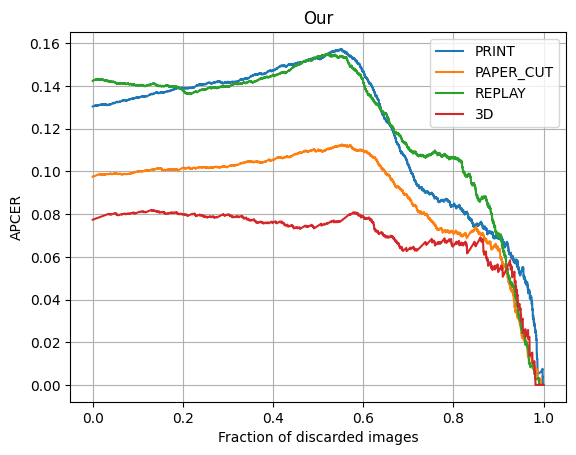

In [ ]:
fig, ax = plt.subplots()
dic_edc_results = OUR_AND_IQA_real_edc_st
for i_st in dic_edc_results:
    # Data for plotting
    sample_apcer_st = dic_edc_results[i_st]['IQ-Model-MbNv2']['error_fractions'].tolist()
    total_samples = len(sample_apcer_st)
    t = np.array([round(x/total_samples,4) for x in range(total_samples)])
    apcer_st_plot = sample_apcer_st
    ax.plot(t, apcer_st_plot, label=i_st.upper())

ax.set(xlabel='Fraction of discarded images', ylabel='APCER', title='Our')
ax.grid()
plt.legend(loc='upper right')
plt.savefig('EDC_APCER_our_IQAfilter.png', dpi=800)

In [ ]:
dic_edc_results = OUR_AND_IQA_real_edc_st
results_operation_point = {}
for i_st in dic_edc_results:
    results_operation_point[i_st] = {}
    # print(f"For {i_st.upper()}")
    for i_ref in value_op_list:
        # print(f"For {i_ref} % of reject Metric:", edc_metric_quantile(dic_edc_results[i_st], sample_rejection_pct=i_ref))
        results_operation_point[i_st].update({i_ref:edc_metric_quantile(dic_edc_results[i_st], sample_rejection_pct=i_ref)})
pd.DataFrame(results_operation_point)

,print,paper_cut,replay,3d
0.00,0.130418,0.097588,0.142429,0.077386
0.20,0.139066,0.101508,0.136951,0.079739
0.40,0.148894,0.106533,0.145220,0.076253
0.60,0.140295,0.107286,0.135917,0.076471
0.80,0.081081,0.070854,0.104393,0.066667
0.95,0.035433,0.008048,0.010352,0.010471
0.97,0.006557,0.000000,0.000000,0.000000


#### AENet Model

In [ ]:
AEnet_AND_IQA_real_edc_st = {}
for i_st in AEnet_AND_IQA_attack_st:
    AEnet_AND_IQA_real_edc_st[i_st] = plot_edc_metrics(AEnet_AND_IQA_attack_st[i_st])

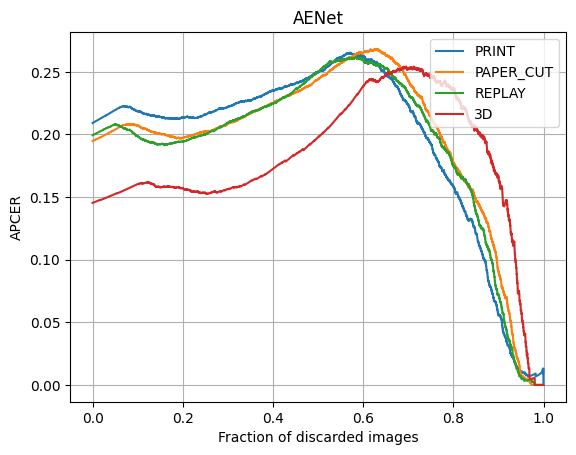

In [ ]:
fig, ax = plt.subplots()
dic_edc_results = AEnet_AND_IQA_real_edc_st
for i_st in dic_edc_results:
    sample_apcer_st = dic_edc_results[i_st]['IQ-Model-MbNv2']['error_fractions'].tolist()
    total_samples = len(sample_apcer_st)
    t = np.array([round(x/total_samples,4) for x in range(total_samples)])
    apcer_st_plot = sample_apcer_st
    ax.plot(t, apcer_st_plot, label=i_st.upper())

ax.set(xlabel='Fraction of discarded images', ylabel='APCER', title='AENet')
ax.grid()
plt.legend(loc='upper right')
plt.savefig('EDC_APCER_AENet_IQAfilter.png', dpi=400)

In [ ]:
dic_edc_results = AEnet_AND_IQA_real_edc_st
results_operation_point = {}
for i_st in dic_edc_results:
    results_operation_point[i_st] = {}
    # print(f"For {i_st.upper()}")
    for i_ref in value_op_list:
        # print(f"For {i_ref} % of reject Metric:", edc_metric_quantile(dic_edc_results[i_st], sample_rejection_pct=i_ref))
        results_operation_point[i_st].update({i_ref:edc_metric_quantile(dic_edc_results[i_st], sample_rejection_pct=i_ref)})
pd.DataFrame(results_operation_point)

,print,paper_cut,replay,3d
0.00,0.209140,0.194673,0.199380,0.145359
0.20,0.213759,0.197990,0.194703,0.156209
0.40,0.236527,0.227136,0.225840,0.176035
0.60,0.259705,0.267337,0.257106,0.243137
0.80,0.139066,0.162814,0.165375,0.219608
0.95,0.007874,0.000000,0.004141,0.005236
0.97,0.009836,0.000000,0.000000,0.000000


### BPCER

In [ ]:
OUR_AND_IQA_real_edc = plot_edc_metrics(OUR_AND_IQA_real)
AEnet_AND_IQA_real_edc = plot_edc_metrics(AEnet_AND_IQA_real)

In [ ]:
aenet_BPCER = AEnet_AND_IQA_real_edc['IQ-Model-MbNv2']['error_fractions'].tolist()
our_BPCER = OUR_AND_IQA_real_edc['IQ-Model-MbNv2']['error_fractions'].tolist()

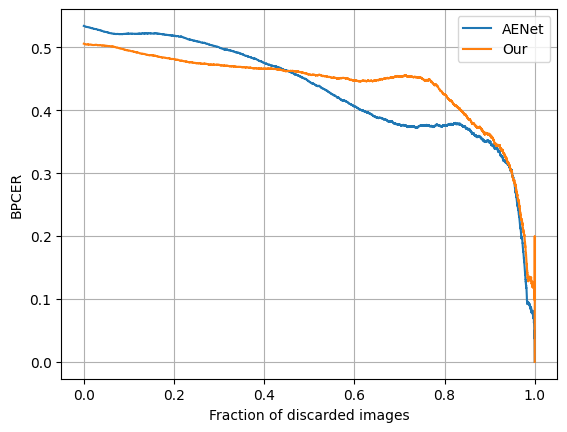

In [ ]:
# Data for plotting
total_samples = len(aenet_BPCER)
t = np.array([round(x/total_samples,4) for x in range(total_samples)])
aenet_plot = aenet_BPCER
our_plot = our_BPCER

fig, ax = plt.subplots()
ax.plot(t, aenet_plot, label='AENet')
ax.plot(t, our_plot, label='Our')

ax.set(xlabel='Fraction of discarded images', ylabel='BPCER')
ax.grid()
plt.legend(loc='upper right')
plt.savefig('EDC_BPCER_All_Models_IQAfilter.png', dpi=400)

In [13]:
dic_edc_results = {
    'AENet': AEnet_AND_IQA_real_edc,
    'OUR': OUR_AND_IQA_real_edc,
}
results_operation_point = {}
for i_st in dic_edc_results:
    results_operation_point[i_st] = {}
    # print(f"For {i_st.upper()}")
    for i_ref in value_op_list:
        # print(f"For {i_ref} % of reject Metric:", edc_metric_quantile(dic_edc_results[i_st], sample_rejection_pct=i_ref))
        results_operation_point[i_st].update({i_ref:edc_metric_quantile(dic_edc_results[i_st], sample_rejection_pct=i_ref)})
pd.DataFrame(results_operation_point)

,AENet,OUR
,,
0.00,0.533924,0.505649
0.20,0.517557,0.480076
0.40,0.472570,0.465954
0.60,0.400305,0.446260
0.80,0.378015,0.410382
0.95,0.189487,0.217604
0.97,0.079430,0.124236


END